# Relationship Discovery

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

FILE_PATH = "../data/raw/CPRI_Hackathon_Screening_Dataset_PARTICIPANT.xlsx"

train = pd.read_excel(
    FILE_PATH,
    sheet_name="Training_Data"
)

test = pd.read_excel(
    FILE_PATH,
    sheet_name="Test_Data"
)

submission = pd.read_excel(
    FILE_PATH,
    sheet_name="Sample_Submission"
)

# Physical input features
feature_cols = [
    "Applied_Voltage_kV",
    "Load_Current_A",
    "Ambient_Temperature_C",
    "Test_Duration_min",
    "Sensor_S1",
    "Sensor_S2",
    "Sensor_S3",
    "Sensor_S4"
]

# Sensor features
sensor_cols = [
    "Sensor_S1",
    "Sensor_S2",
    "Sensor_S3",
    "Sensor_S4"
]

# Targets
target_regression = "Reference_Parameter"
target_classification = "Validity_Label"

print("Training columns:")
print(train.columns.tolist())

print("\nFeature columns:")
print(feature_cols)

print("\nTarget columns:")
print(target_regression)
print(target_classification)

print("Training shape:", train.shape)
print("Test shape:", test.shape)
print("Submission shape:", submission.shape)

display(train.head())

Training columns:
['Test_ID', 'Applied_Voltage_kV', 'Load_Current_A', 'Ambient_Temperature_C', 'Test_Duration_min', 'Sensor_S1', 'Sensor_S2', 'Sensor_S3', 'Sensor_S4', 'Reference_Parameter', 'Validity_Label']

Feature columns:
['Applied_Voltage_kV', 'Load_Current_A', 'Ambient_Temperature_C', 'Test_Duration_min', 'Sensor_S1', 'Sensor_S2', 'Sensor_S3', 'Sensor_S4']

Target columns:
Reference_Parameter
Validity_Label
Training shape: (1000, 11)
Test shape: (350, 9)
Submission shape: (350, 3)


,Test_ID,Applied_Voltage_kV,Load_Current_A,Ambient_Temperature_C,Test_Duration_min,Sensor_S1,Sensor_S2,Sensor_S3,Sensor_S4,Reference_Parameter,Validity_Label
0,TRN-0889,16.7196,93.1228,33.3421,19.9546,13.6343,15.1361,16.5062,62.9115,34.8501,Valid
1,TRN-0820,21.4477,82.5230,34.4915,47.0553,15.6466,15.9849,19.3289,39.8667,30.4762,Valid
2,TRN-0411,19.2432,107.3619,29.4673,5.2763,15.1080,16.6481,18.3834,44.5390,46.8046,Valid
3,TRN-0754,22.7191,69.9690,26.9695,20.3051,14.9296,14.7026,18.6269,44.2673,23.7153,Valid
4,TRN-0707,13.5008,108.8999,35.5415,29.1939,12.6845,15.2455,14.6132,44.0720,48.5994,Valid


**Load_Current_A → Reference_Parameter** - Strongest linear correlation

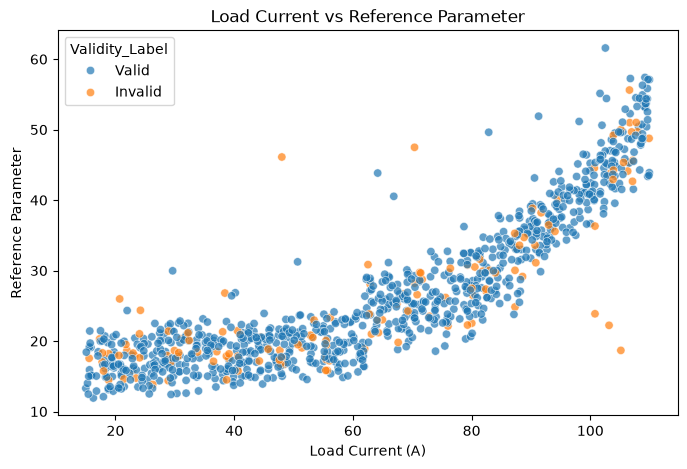

In [26]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train,
    x="Load_Current_A",
    y="Reference_Parameter",
    hue="Validity_Label",
    alpha=0.7
)

plt.title("Load Current vs Reference Parameter")
plt.xlabel("Load Current (A)")
plt.ylabel("Reference Parameter")
plt.show()

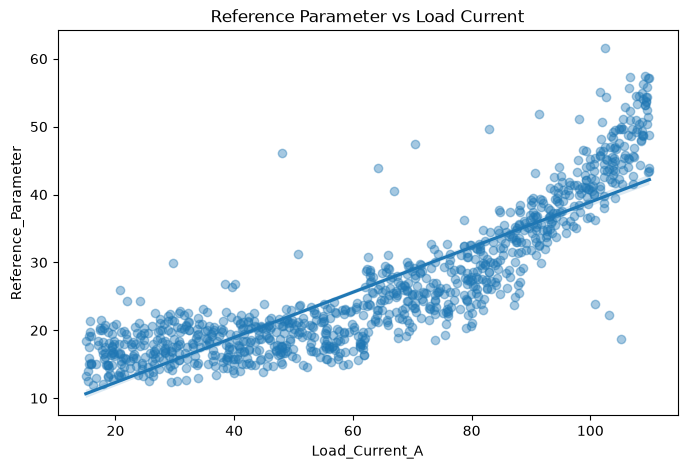

In [27]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=train,
    x="Load_Current_A",
    y="Reference_Parameter",
    scatter_kws={"alpha": 0.4},
    line_kws={}
)

plt.title("Reference Parameter vs Load Current")
plt.show()

**The Reference Parameter has a strong nonlinear relationship with Current**

***Comparing Valid and Invalid separately***

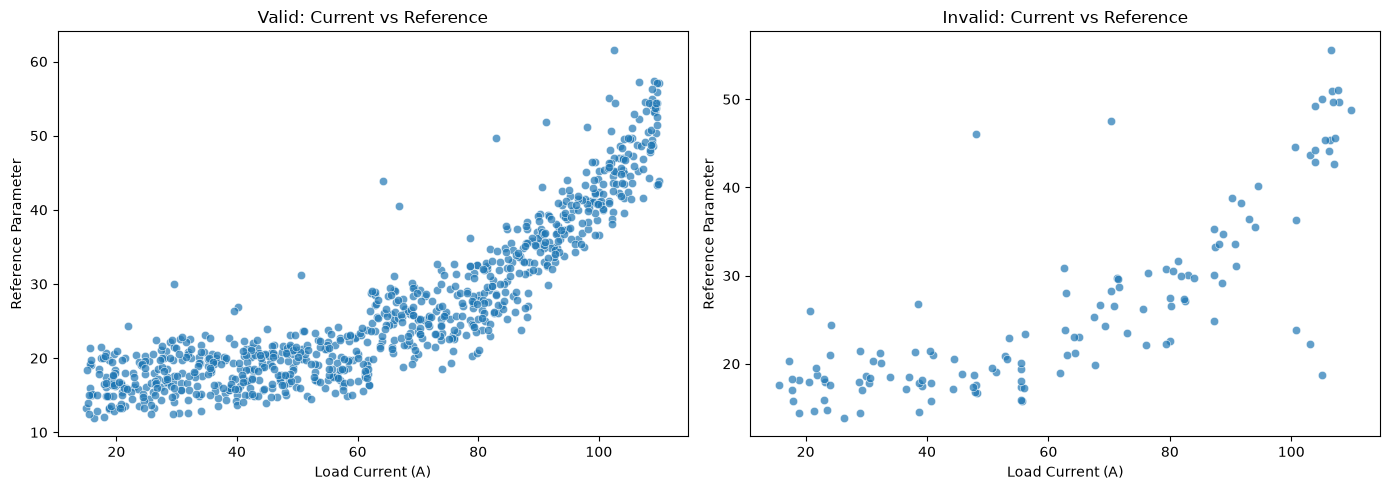

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label in zip(axes, ["Valid", "Invalid"]):

    subset = train[
        train["Validity_Label"] == label
    ]

    sns.scatterplot(
        data=subset,
        x="Load_Current_A",
        y="Reference_Parameter",
        alpha=0.7,
        ax=ax
    )

    ax.set_title(f"{label}: Current vs Reference")
    ax.set_xlabel("Load Current (A)")
    ax.set_ylabel("Reference Parameter")

plt.tight_layout()
plt.show()

***Quantifing that relationship***

In [29]:
for label in ["Valid", "Invalid"]:

    subset = train[
        train["Validity_Label"] == label
    ]

    corr = subset[
        ["Load_Current_A", "Reference_Parameter"]
    ].corr().iloc[0, 1]

    print(f"{label}: {corr:.4f}")

Valid: 0.8767
Invalid: 0.8016


***Reference vs all important features***

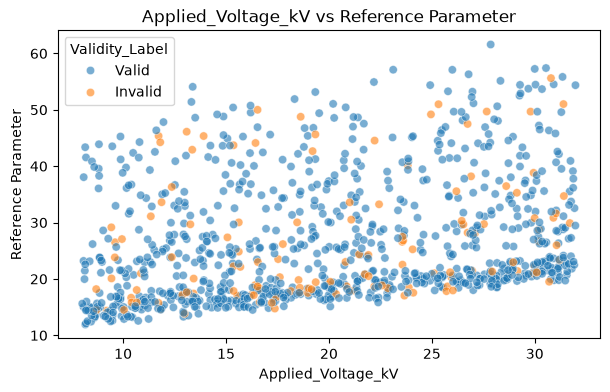

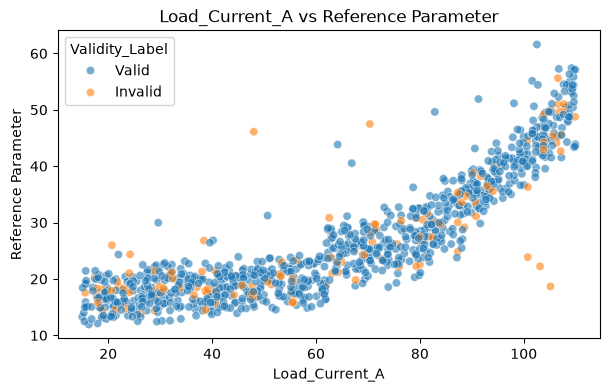

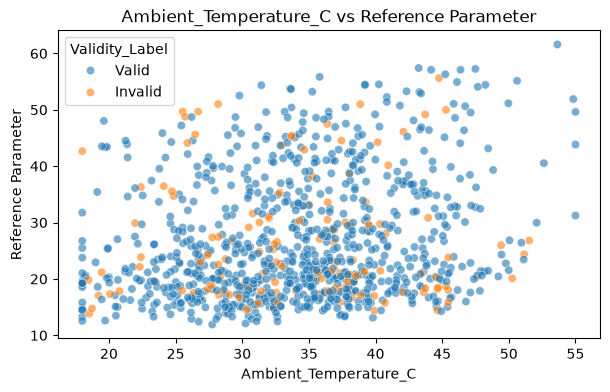

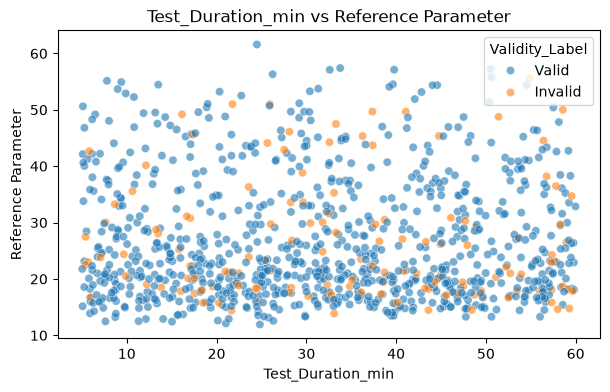

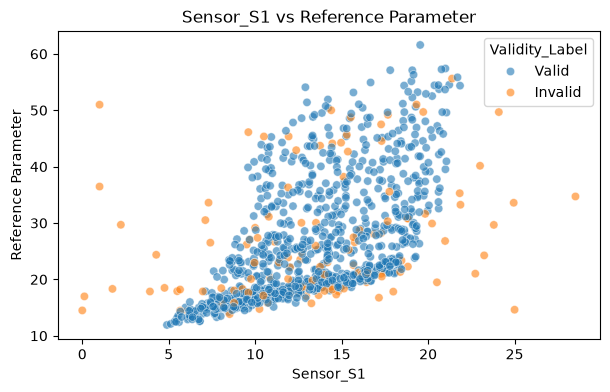

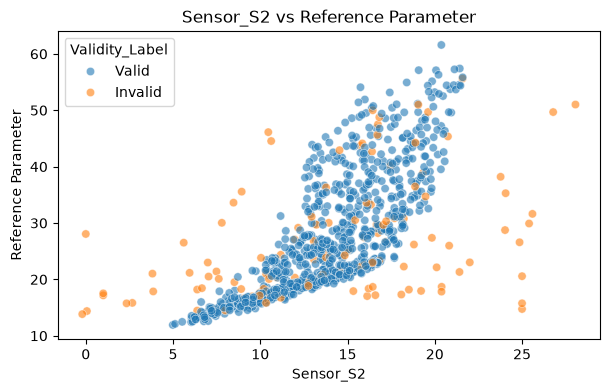

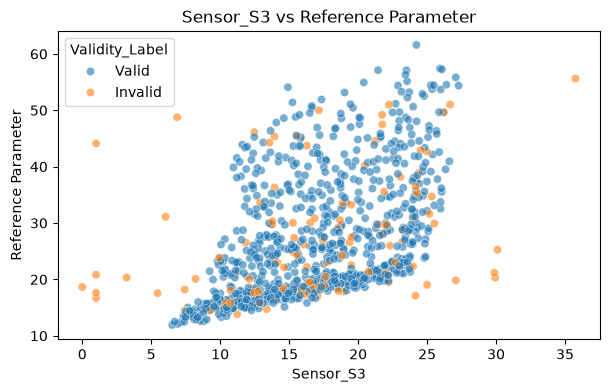

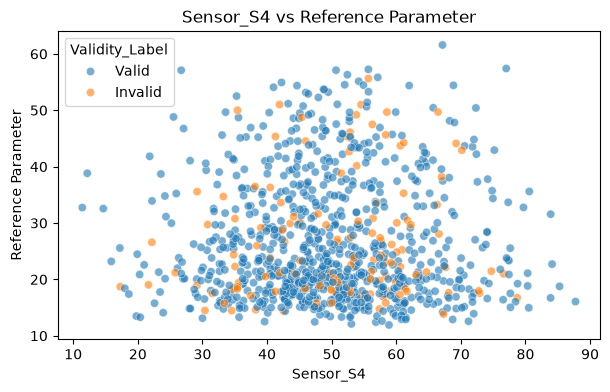

In [30]:
for col in feature_cols:

    plt.figure(figsize=(7, 4))

    sns.scatterplot(
        data=train,
        x=col,
        y="Reference_Parameter",
        hue="Validity_Label",
        alpha=0.6
    )

    plt.title(f"{col} vs Reference Parameter")
    plt.xlabel(col)
    plt.ylabel("Reference Parameter")

    plt.show()

***Sensor-to-sensor relationships***

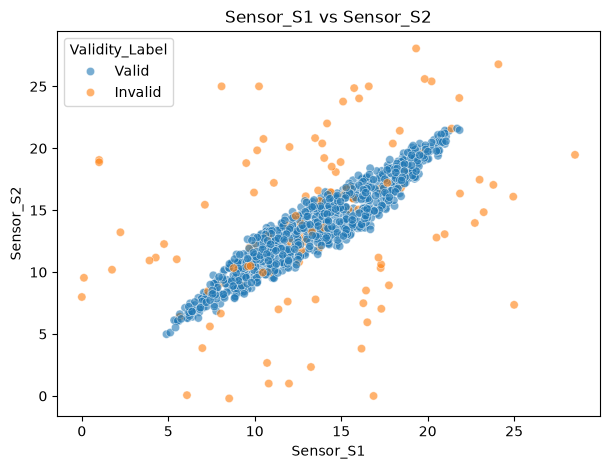

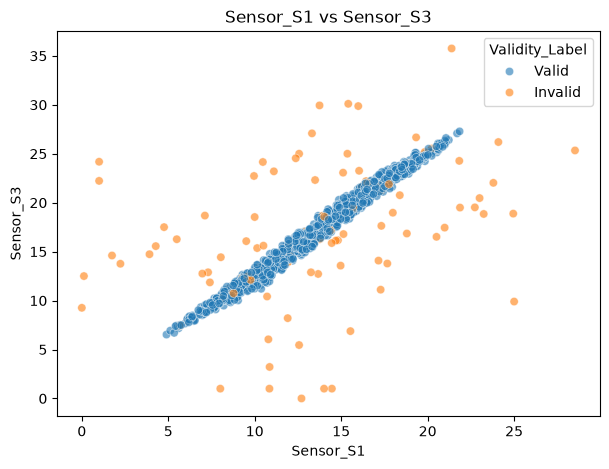

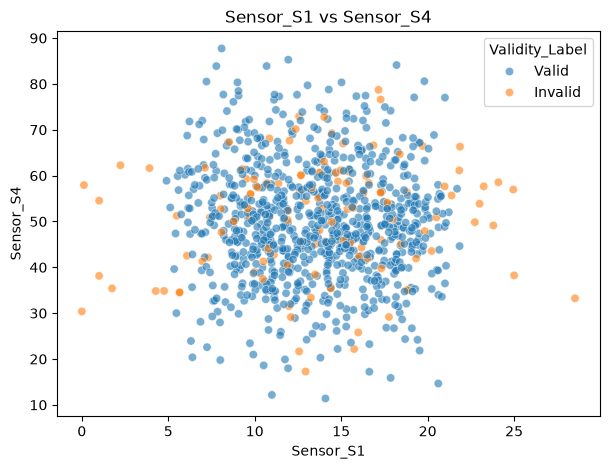

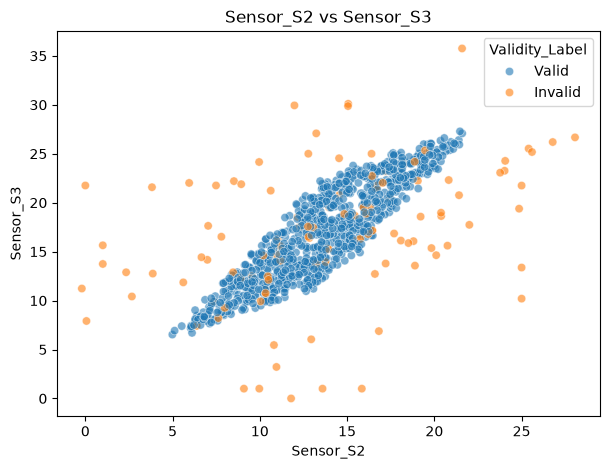

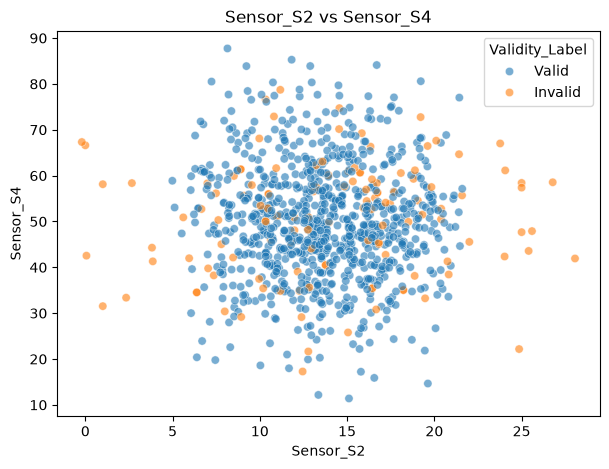

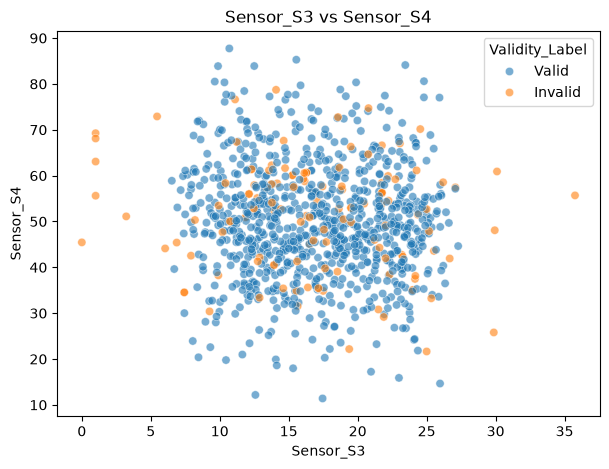

In [31]:
sensor_pairs = [
    ("Sensor_S1", "Sensor_S2"),
    ("Sensor_S1", "Sensor_S3"),
    ("Sensor_S1", "Sensor_S4"),
    ("Sensor_S2", "Sensor_S3"),
    ("Sensor_S2", "Sensor_S4"),
    ("Sensor_S3", "Sensor_S4")
]

for x, y in sensor_pairs:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        data=train,
        x=x,
        y=y,
        hue="Validity_Label",
        alpha=0.6
    )

    plt.title(f"{x} vs {y}")
    plt.show()

1) *Normal:
S2 ≈ f(S1)

Invalid:
S2 deviates from f(S1)*

***Quantify sensor relationships***

In [32]:
sensor_corr = train[sensor_cols].corr()

display(sensor_corr)

,Sensor_S1,Sensor_S2,Sensor_S3,Sensor_S4
Sensor_S1,1.000000,0.787012,0.867966,-0.031900
Sensor_S2,0.787012,1.000000,0.770239,-0.026449
Sensor_S3,0.867966,0.770239,1.000000,-0.070673
Sensor_S4,-0.031900,-0.026449,-0.070673,1.000000


***Voltage → sensors***

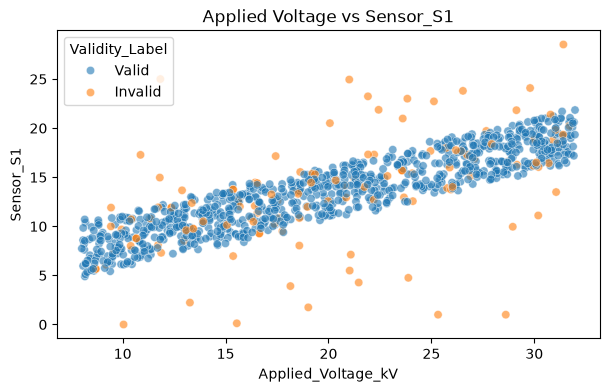

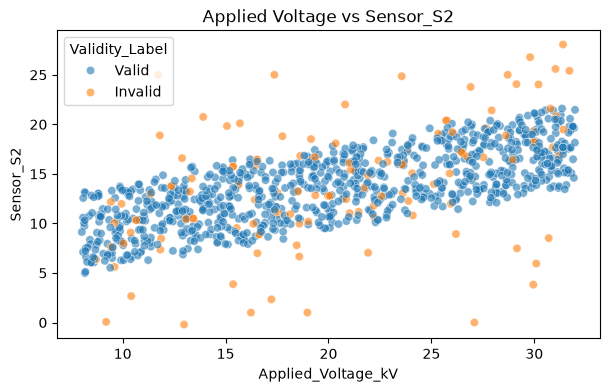

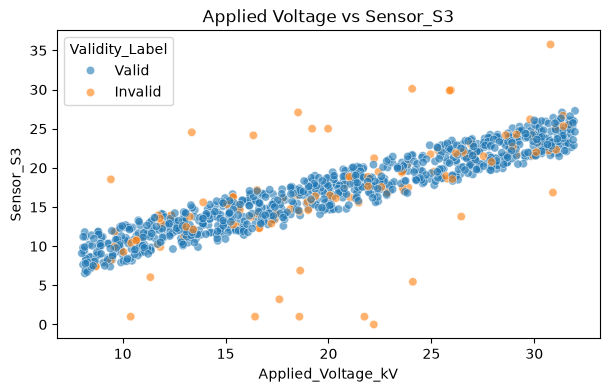

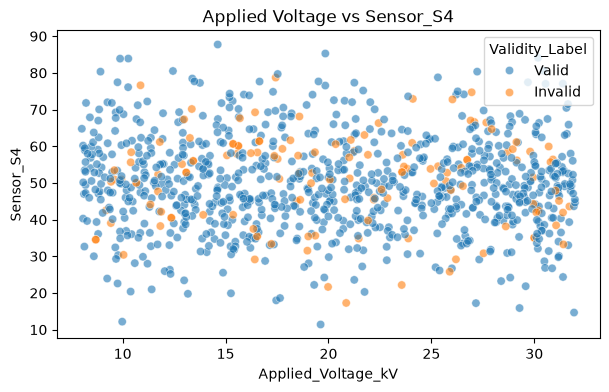

In [33]:
for sensor in sensor_cols:

    plt.figure(figsize=(7, 4))

    sns.scatterplot(
        data=train,
        x="Applied_Voltage_kV",
        y=sensor,
        hue="Validity_Label",
        alpha=0.6
    )

    plt.title(
        f"Applied Voltage vs {sensor}"
    )

    plt.show()

***Current → sensors***

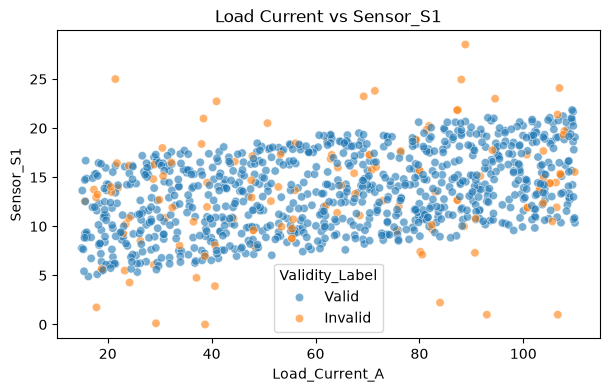

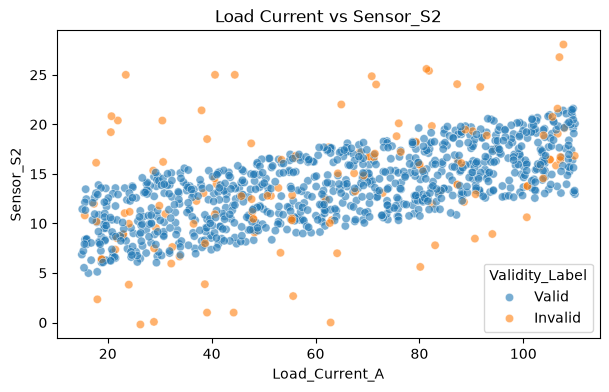

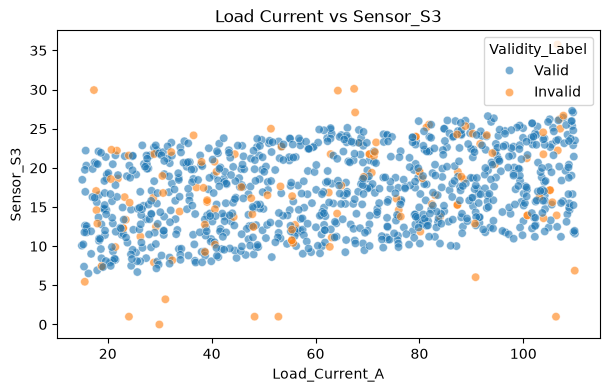

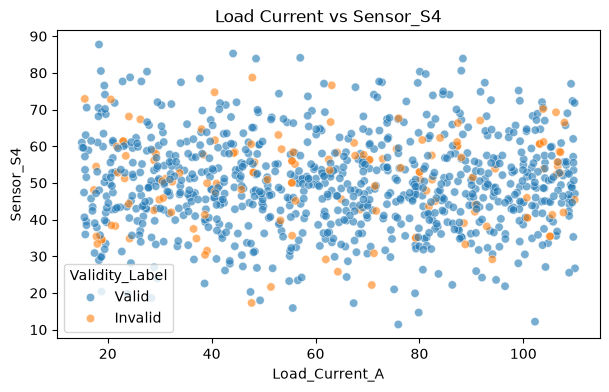

In [34]:
for sensor in sensor_cols:

    plt.figure(figsize=(7, 4))

    sns.scatterplot(
        data=train,
        x="Load_Current_A",
        y=sensor,
        hue="Validity_Label",
        alpha=0.6
    )

    plt.title(
        f"Load Current vs {sensor}"
    )

    plt.show()

***Physical feature: apparent power***

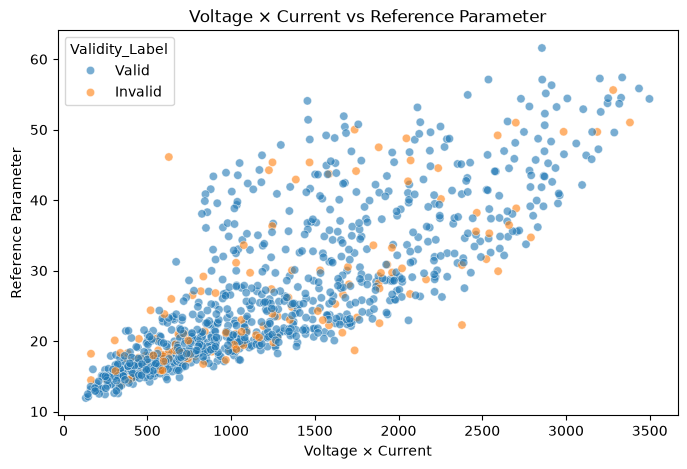

In [35]:
train["Power_proxy"] = (
    train["Applied_Voltage_kV"]
    * train["Load_Current_A"]
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=train,
    x="Power_proxy",
    y="Reference_Parameter",
    hue="Validity_Label",
    alpha=0.6
)

plt.title(
    "Voltage × Current vs Reference Parameter"
)

plt.xlabel("Voltage × Current")
plt.ylabel("Reference Parameter")

plt.show()

***Sensor spread / consistency***

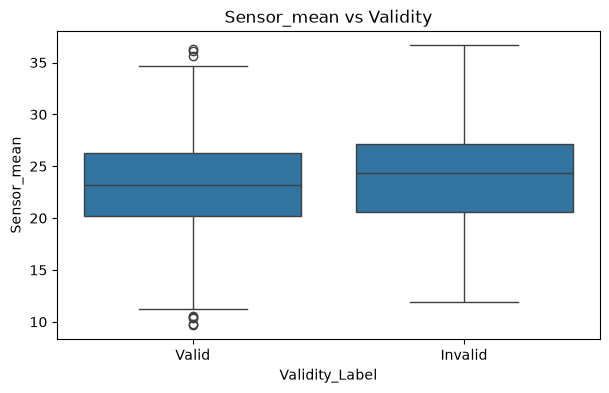

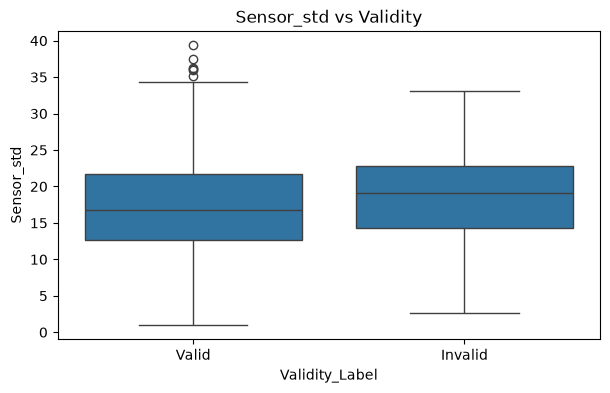

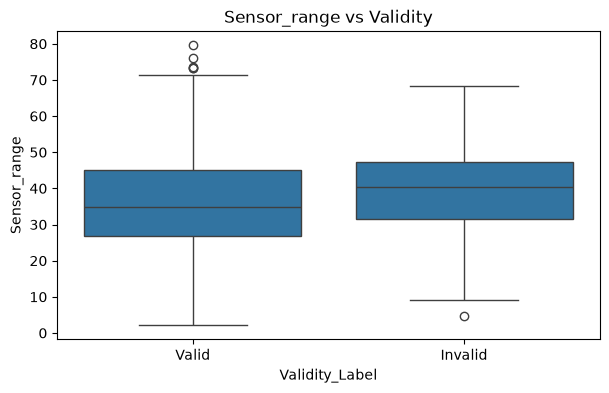

In [36]:
train["Sensor_mean"] = train[sensor_cols].mean(axis=1)

train["Sensor_std"] = train[sensor_cols].std(axis=1)

train["Sensor_range"] = (
    train[sensor_cols].max(axis=1)
    - train[sensor_cols].min(axis=1)
)

# Compare Valid vs Invalid
for col in [
    "Sensor_mean",
    "Sensor_std",
    "Sensor_range"
]:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=train,
        x="Validity_Label",
        y=col
    )

    plt.title(
        f"{col} vs Validity"
    )

    plt.show()

***Sensor differences***

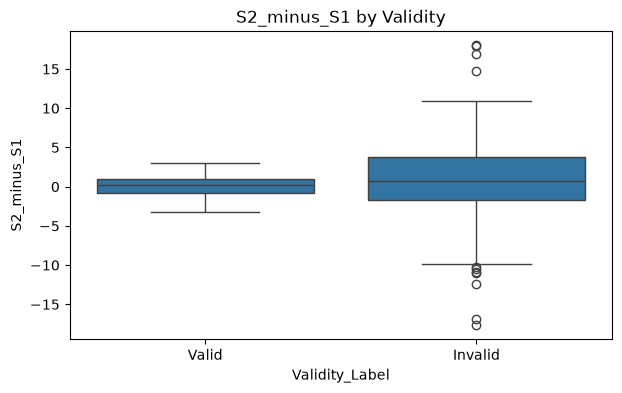

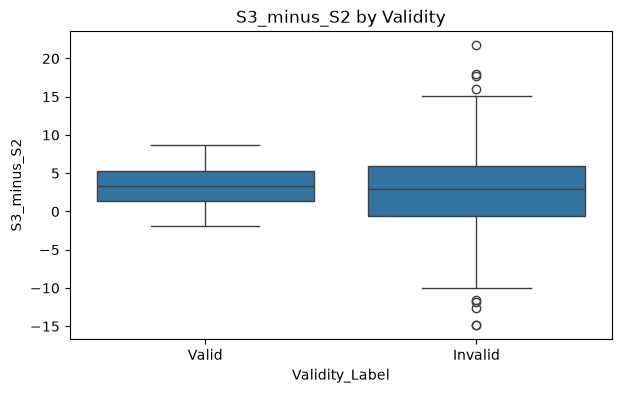

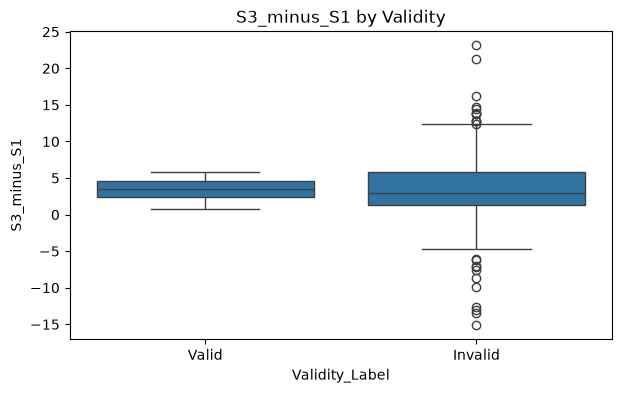

In [37]:
train["S2_minus_S1"] = (
    train["Sensor_S2"]
    - train["Sensor_S1"]
)

train["S3_minus_S2"] = (
    train["Sensor_S3"]
    - train["Sensor_S2"]
)

train["S3_minus_S1"] = (
    train["Sensor_S3"]
    - train["Sensor_S1"]
)

difference_cols = [
    "S2_minus_S1",
    "S3_minus_S2",
    "S3_minus_S1"
]

# Are Invalid tests violating the normal relative relationship between sensors?
for col in difference_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=train,
        x="Validity_Label",
        y=col
    )

    plt.title(
        f"{col} by Validity"
    )

    plt.show()

***Missingness as a relationship***

In [38]:
for sensor in sensor_cols:

    missing_rate = (
        train.groupby("Validity_Label")[sensor]
        .apply(lambda x: x.isna().mean() * 100)
    )

    print(f"\n{sensor}")
    display(missing_rate)


Sensor_S1


Validity_Label
Invalid    4.477612
Valid      0.000000
Name: Sensor_S1, dtype: float64


Sensor_S2


Validity_Label
Invalid    1.492537
Valid      0.000000
Name: Sensor_S2, dtype: float64


Sensor_S3


Validity_Label
Invalid    5.223881
Valid      0.000000
Name: Sensor_S3, dtype: float64


Sensor_S4


Validity_Label
Invalid    0.00000
Valid      3.34873
Name: Sensor_S4, dtype: float64

***Residual analysis***

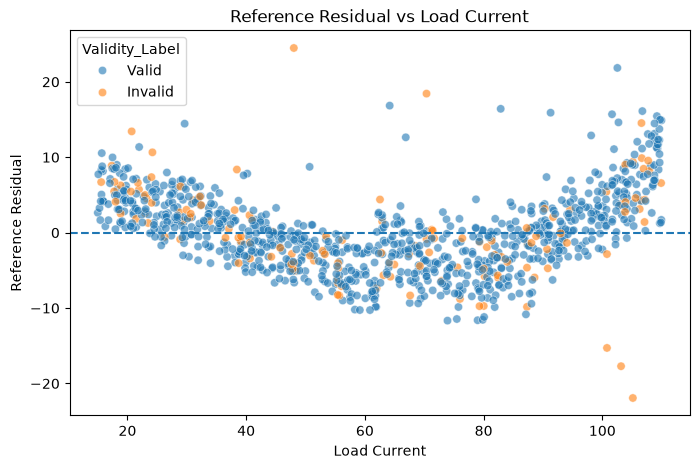

In [39]:
from sklearn.linear_model import LinearRegression

valid_data = train.dropna(
    subset=[
        "Load_Current_A",
        "Reference_Parameter"
    ]
)

X = valid_data[["Load_Current_A"]]
y = valid_data["Reference_Parameter"]

model = LinearRegression()
model.fit(X, y)

valid_data = valid_data.copy()

valid_data["Reference_pred"] = model.predict(X)

valid_data["Reference_residual"] = (
    valid_data["Reference_Parameter"]
    - valid_data["Reference_pred"]
)

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=valid_data,
    x="Load_Current_A",
    y="Reference_residual",
    hue="Validity_Label",
    alpha=0.6
)

plt.axhline(0, linestyle="--")

plt.title(
    "Reference Residual vs Load Current"
)

plt.xlabel("Load Current")
plt.ylabel("Reference Residual")

plt.show()

# Takeaways

                 Applied Voltage
                        │
                        ▼
                 ┌─────────────┐
                 │   System    │
                 │   state     │
                 └──────┬──────┘
                        │
             ┌──────────┼──────────┐
             ▼          ▼          ▼
            S1         S2         S3
             │          │          │
             └──────────┼──────────┘
                        │
                        ▼
                  Reference
                        ▲
                        │
                  Load Current

S4 ── unclear / auxiliary

             Measurement process
                    │
             ┌──────┴──────┐
             │             │
          normal        corrupted
             │             │
          Valid          Invalid

Corruption appears to manifest as:

• sensor disagreement
• abnormal sensor relationships
• unusual reference relative to current
• possibly missing core sensors
• potentially corrupted Reference itself

***Learning the dominant relationships from Valid observations, then measure how much every observation deviates from those relationships.***

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

FILE_PATH = "../data/raw/CPRI_Hackathon_Screening_Dataset_PARTICIPANT.xlsx"

train = pd.read_excel(
    FILE_PATH,
    sheet_name="Training_Data"
)

test = pd.read_excel(
    FILE_PATH,
    sheet_name="Test_Data"
)

print("Train:", train.shape)
print("Test:", test.shape)

Train: (1000, 11)
Test: (350, 9)


In [42]:
feature_cols = [
    "Applied_Voltage_kV",
    "Load_Current_A",
    "Ambient_Temperature_C",
    "Test_Duration_min",
    "Sensor_S1",
    "Sensor_S2",
    "Sensor_S3",
    "Sensor_S4"
]

sensor_cols = [
    "Sensor_S1",
    "Sensor_S2",
    "Sensor_S3",
    "Sensor_S4"
]

valid_train = train[
    train["Validity_Label"] == "Valid"
].copy()

print("Valid observations:", len(valid_train))
print("Invalid observations:", len(train) - len(valid_train))

Valid observations: 866
Invalid observations: 134


In [43]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [44]:
def fit_relationship(data, x_col, y_col, degree=2):
    
    subset = data[[x_col, y_col]].dropna()
    
    X = subset[[x_col]]
    y = subset[y_col]
    
    model = make_pipeline(
        PolynomialFeatures(degree=degree),
        LinearRegression()
    )
    
    model.fit(X, y)
    
    return model

In [47]:
s2_from_s1 = fit_relationship(
    valid_train,
    "Sensor_S1",
    "Sensor_S2"
)

s3_from_s1 = fit_relationship(
    valid_train,
    "Sensor_S1",
    "Sensor_S3"
)

s3_from_s2 = fit_relationship(
    valid_train,
    "Sensor_S2",
    "Sensor_S3"
)

reference_from_current = fit_relationship(
    valid_train,
    "Load_Current_A",
    "Reference_Parameter",
    degree=3
)


In [45]:
# Residual=Actual−Predicted

def add_residual_feature(df, model, x_col, y_col, residual_name):
    
    result = df.copy()
    
    mask = result[x_col].notna()
    
    result[residual_name] = np.nan
    
    result.loc[mask, residual_name] = (
        result.loc[mask, y_col]
        - model.predict(
            result.loc[mask, [x_col]]
        )
    )
    
    return result

In [48]:
train_rel = train.copy()

train_rel = add_residual_feature(
    train_rel,
    s2_from_s1,
    "Sensor_S1",
    "Sensor_S2",
    "S2_S1_residual"
)

train_rel = add_residual_feature(
    train_rel,
    s3_from_s1,
    "Sensor_S1",
    "Sensor_S3",
    "S3_S1_residual"
)

train_rel = add_residual_feature(
    train_rel,
    s3_from_s2,
    "Sensor_S2",
    "Sensor_S3",
    "S3_S2_residual"
)

train_rel = add_residual_feature(
    train_rel,
    reference_from_current,
    "Load_Current_A",
    "Reference_Parameter",
    "Reference_Current_residual"
)

In [49]:
test_rel = test.copy()

test_rel = add_residual_feature(
    test_rel,
    s2_from_s1,
    "Sensor_S1",
    "Sensor_S2",
    "S2_S1_residual"
)

test_rel = add_residual_feature(
    test_rel,
    s3_from_s1,
    "Sensor_S1",
    "Sensor_S3",
    "S3_S1_residual"
)

test_rel = add_residual_feature(
    test_rel,
    s3_from_s2,
    "Sensor_S2",
    "Sensor_S3",
    "S3_S2_residual"
)

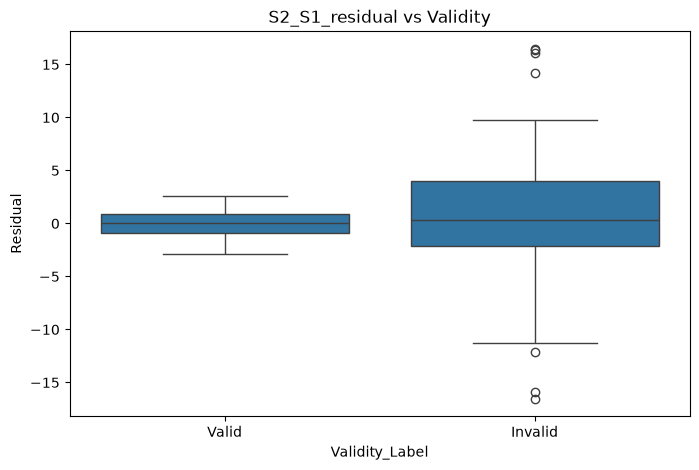

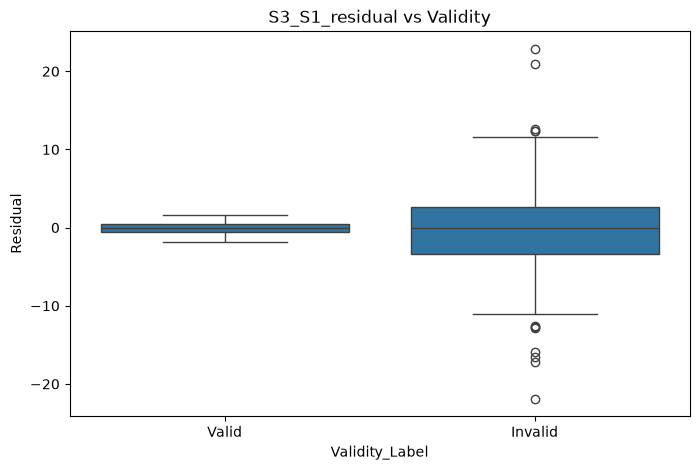

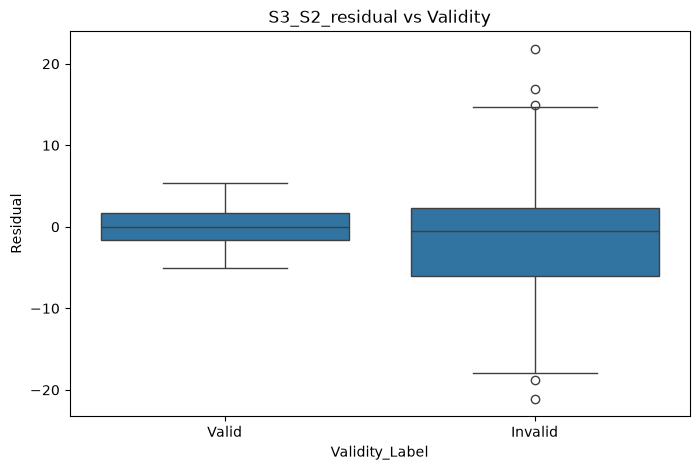

In [50]:
residual_cols = [
    "S2_S1_residual",
    "S3_S1_residual",
    "S3_S2_residual"
]

for col in residual_cols:
    
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=train_rel,
        x="Validity_Label",
        y=col
    )
    
    plt.title(f"{col} vs Validity")
    plt.ylabel("Residual")
    plt.show()

In [51]:
for col in residual_cols:
    
    train_rel[f"{col}_abs"] = train_rel[col].abs()
    
    summary = (
        train_rel
        .groupby("Validity_Label")[f"{col}_abs"]
        .agg(["mean", "median", "std"])
    )
    
    print(f"\n{col}")
    display(summary)


S2_S1_residual


,mean,median,std
Validity_Label,,,
Invalid,4.590264,3.803391,4.197117
Valid,0.982634,0.898021,0.624814



S3_S1_residual


,mean,median,std
Validity_Label,,,
Invalid,5.162509,3.074976,5.304788
Valid,0.550340,0.518944,0.346237



S3_S2_residual


,mean,median,std
Validity_Label,,,
Invalid,5.825577,4.516027,5.079336
Valid,1.807819,1.639202,1.253076


In [52]:
from sklearn.metrics import roc_auc_score

for col in residual_cols:
    
    temp = train_rel[[col, "Validity_Label"]].dropna()
    
    y = (
        temp["Validity_Label"] == "Invalid"
    ).astype(int)
    
    score = roc_auc_score(
        y,
        temp[col].abs()
    )
    
    print(f"{col}: AUC = {score:.4f}")

S2_S1_residual: AUC = 0.7578
S3_S1_residual: AUC = 0.7919
S3_S2_residual: AUC = 0.7355


In [54]:
train_rel["S2_minus_S1"] = (
    train_rel["Sensor_S2"] -
    train_rel["Sensor_S1"]
)

train_rel["S3_minus_S1"] = (
    train_rel["Sensor_S3"] -
    train_rel["Sensor_S1"]
)

train_rel["S3_minus_S2"] = (
    train_rel["Sensor_S3"] -
    train_rel["Sensor_S2"]
)

test_rel["S2_minus_S1"] = (
    test_rel["Sensor_S2"] -
    test_rel["Sensor_S1"]
)

test_rel["S3_minus_S1"] = (
    test_rel["Sensor_S3"] -
    test_rel["Sensor_S1"]
)

test_rel["S3_minus_S2"] = (
    test_rel["Sensor_S3"] -
    test_rel["Sensor_S2"]
)


In [55]:
train_rel["Voltage_Current"] = (
    train_rel["Applied_Voltage_kV"] *
    train_rel["Load_Current_A"]
)

test_rel["Voltage_Current"] = (
    test_rel["Applied_Voltage_kV"] *
    test_rel["Load_Current_A"]
)

In [56]:
for col in sensor_cols:
    
    train_rel[f"{col}_missing"] = (
        train_rel[col].isna().astype(int)
    )
    
    test_rel[f"{col}_missing"] = (
        test_rel[col].isna().astype(int)
    )

In [57]:
import os

os.makedirs("../data/processed", exist_ok=True)

train_rel.to_csv(
    "../data/processed/train_relationship_features.csv",
    index=False
)

test_rel.to_csv(
    "../data/processed/test_relationship_features.csv",
    index=False
)

print("Saved relationship-engineered datasets.")

Saved relationship-engineered datasets.
